# Análisis estadístico de señales  
## Práctica 3 - PARTE 2 (SEÑAL EEG)

**Integrantes:**  
- Sara Mejía Zapata  
- María Camila Tobón Úsuga

**Asignatura:** Bioseñales y Sistemas


---

In [89]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import pandas as pd 
import numpy as np

In [90]:
import mne
import os

base_path = 'Lab_EEG_Imagineria'

sujeto = 'sub_1'
ruta_sujeto = os.path.join(base_path, sujeto)

# escoger un archivo .set (por ejemplo el primero)
archivos = os.listdir(ruta_sujeto)

for archivo in archivos:
    if archivo.endswith('.set'):
        ruta_archivo = os.path.join(ruta_sujeto, archivo)
        break

raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True)

# eventos
events, event_id = mne.events_from_annotations(raw)

print("Eventos Encontrados :", event_id)

Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Eventos Encontrados : {np.str_('TASK2T0'): 1, np.str_('TASK2T1'): 2, np.str_('TASK2T2'): 3}


In [91]:
# Función RMS
def calcular_rms(epocas):
    rms_epoca = np.sqrt(np.mean(epocas**2, axis=2))
    rms_prom = np.mean(rms_epoca, axis=0)
    return rms_prom

In [92]:
# Listas para almacenar resultados
rms_T1_list = []
rms_T2_list = []
canales = None

# Recorrer sujetos
for sujeto in os.listdir(base_path):
    
    ruta_sujeto = os.path.join(base_path, sujeto)
    
    if os.path.isdir(ruta_sujeto):
        
        # Buscar archivos .set dentro del sujeto
        for archivo in os.listdir(ruta_sujeto):
            
            if archivo.endswith('.set') and 'run-4' in archivo:
                
                ruta_archivo = os.path.join(ruta_sujeto, archivo)
                
                # Cargar señal
                raw = mne.io.read_raw_eeglab(ruta_archivo, preload=True)
                
                # Eventos
                events, event_id = mne.events_from_annotations(raw)
                
                # Crear épocas
                epocas = mne.Epochs(raw, events, event_id, preload=True)
                
                # Separar clases
                epocas_T1 = epocas['TASK2T1']
                epocas_T2 = epocas['TASK2T2']
                
                # Guardar nombres de canales (solo una vez)
                if canales is None:
                    canales = epocas.ch_names
                
                # Calcular RMS
                rms_T1 = calcular_rms(epocas_T1.get_data())
                rms_T2 = calcular_rms(epocas_T2.get_data())
                
                # Guardar resultados
                rms_T1_list.append(rms_T1)
                rms_T2_list.append(rms_T2)

Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
Used Annotations descriptions: [np.str_('TASK2T0'), np.str_('TASK2T1'), np.str_('TASK2T2')]
Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 

In [93]:
df_T1 = pd.DataFrame(rms_T1_list, columns=canales)
df_T2 = pd.DataFrame(rms_T2_list, columns=canales)

print(df_T1)
print(df_T2)

        Fc5       Fc3       Fc1       Fcz       Fc2       Fc4       Fc6  \
0  0.000048  0.000050  0.000052  0.000050  0.000050  0.000045  0.000036   
1  0.000063  0.000051  0.000060  0.000059  0.000050  0.000044  0.000069   
2  0.000022  0.000022  0.000022  0.000023  0.000021  0.000019  0.000016   
3  0.000073  0.000069  0.000061  0.000059  0.000059  0.000046  0.000045   
4  0.000029  0.000028  0.000029  0.000022  0.000022  0.000021  0.000021   
5  0.000069  0.000032  0.000048  0.000045  0.000037  0.000048  0.000047   
6  0.000025  0.000023  0.000023  0.000022  0.000021  0.000021  0.000020   
7  0.000041  0.000040  0.000040  0.000039  0.000039  0.000039  0.000037   
8  0.000038  0.000032  0.000033  0.000033  0.000033  0.000033  0.000037   
9  0.000099  0.000070  0.000063  0.000062  0.000065  0.000065  0.000109   

         C5        C3        C1  ...        P8       Po7       Po3       Poz  \
0  0.000048  0.000052  0.000054  ...  0.000041  0.000057  0.000058  0.000057   
1  0.000049  0

In [94]:
print(df_T1.shape)
print(df_T2.shape)

(10, 64)
(10, 64)


In [95]:
resultados = []

for canal in df_T1.columns:
    
    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # 1 Normalidad
    p_shapiro1 = shapiro(grupo1)[1]
    p_shapiro2 = shapiro(grupo2)[1]
    
    normal = (p_shapiro1 > 0.05) and (p_shapiro2 > 0.05)
    
    # 2 Homocedasticidad
    p_levene = levene(grupo1, grupo2)[1]
    
    var_igual = p_levene > 0.05
    
    # 3 Selección de prueba
    if normal and var_igual:
        stat, p_valor = ttest_ind(grupo1, grupo2)
        prueba = "t-test"
    else:
        stat, p_valor = mannwhitneyu(grupo1, grupo2)
        prueba = "Mann-Whitney"
    
    resultados.append([canal, prueba, p_valor])

Para determinar si existen diferencias significativas entre las tareas de imaginería motora de mano izquierda (T1) y mano derecha (T2), se realizó un análisis estadístico canal por canal utilizando los valores de energía RMS previamente calculados.

Se implementó un proceso iterativo que recorre cada uno de los canales presentes en los DataFrames correspondientes a ambos grupos (df_T1 y df_T2). En cada iteración se seleccionan los valores del mismo canal para los dos grupos y se comparan estadísticamente.

In [96]:
df_resultados = pd.DataFrame(resultados, columns=["Canal","Prueba","p_valor"])
pd.set_option('display.max_rows', None)
print(df_resultados)

   Canal        Prueba   p_valor
0    Fc5  Mann-Whitney  0.969850
1    Fc3  Mann-Whitney  0.909722
2    Fc1        t-test  0.831843
3    Fcz        t-test  0.961711
4    Fc2        t-test  0.987247
5    Fc4        t-test  0.779283
6    Fc6  Mann-Whitney  0.909722
7     C5  Mann-Whitney  0.791337
8     C3        t-test  0.839780
9     C1        t-test  0.821983
10    Cz        t-test  0.990298
11    C2        t-test  0.896751
12    C4        t-test  0.922950
13    C6        t-test  0.784819
14   Cp5        t-test  0.936643
15   Cp3        t-test  0.627524
16   Cp1        t-test  0.844237
17   Cpz        t-test  0.704454
18   Cp2        t-test  0.827655
19   Cp4        t-test  0.973426
20   Cp6        t-test  0.965318
21   Fp1  Mann-Whitney  0.969850
22   Fpz  Mann-Whitney  1.000000
23   Fp2  Mann-Whitney  0.733730
24   Af7  Mann-Whitney  1.000000
25   Af3  Mann-Whitney  0.791337
26   Afz  Mann-Whitney  0.969850
27   Af4  Mann-Whitney  0.623176
28   Af8  Mann-Whitney  0.307489
29    F7  

In [104]:
#PARA IMPRIMIR CANALES CON SIGNIFICANCIA ESTADISTÍCA , ES DECIR CON VALOR P<0.05
canales_significativos = df_resultados[df_resultados["p_valor"] < 0.05]
print(canales_significativos)

Empty DataFrame
Columns: [Canal, Prueba, p_valor]
Index: []


Se evaluó la normalidad de las distribuciones mediante la prueba de shapiroWilk y la homogeneidad de varianzas mediante la prueba de Levene. Dependiendo de el cumplimiento de estos supuestos, se aplicó una prueba t de student para muestras independientes o la prueba no paramétrica U de Mann-Whitney.

Los resultados obtenidos (al imprimir canales significativos) muestran que ningún canal presentó un valor de p<0.05, por lo que no se evidencian diferencias estadísticamente significativas entre las tareas de imaginería motora de mano izquierda y mano derecha para el RMS utilizado.

In [98]:
df_resultados.loc[df_resultados["p_valor"].idxmin()]

Canal               Af8
Prueba     Mann-Whitney
p_valor        0.307489
Name: 28, dtype: object

El canal con menor p-valor fue AF8. Sin embargo, este canal se encuentra en la región frontal y no está directamente asociado con la corteza motora. En estudios de imaginería motora se espera encontrar diferencias en canales centrales como C3 (este es el canal de la corteza motora izquierda) y C4 (canal de la corteza motora derecha). La ausencia de diferencias significativas puede deberse al tamaño reducido de la muestra (solamente 10 sujetos) o a que la métrica RMS global no captura de forma específica la desincronización en las bandas μ y β características de la imaginería motora.

![Boxplot RMS](The-distribution-map-of-64-channel-EEG-electrodes-in-human-brain.webp)

In [103]:
canal_top = df_resultados.sort_values("p_valor").iloc[0]["Canal"]
# Eso significa: Ordenar los canales por p-valor, tomar el más pequeño
# Es decir:canal_top = min(p_valor)

C:\Users\Maria Camila\AppData\Local\Temp\ipykernel_16756\1438064445.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Mano Izquierda","Mano Derecha"])


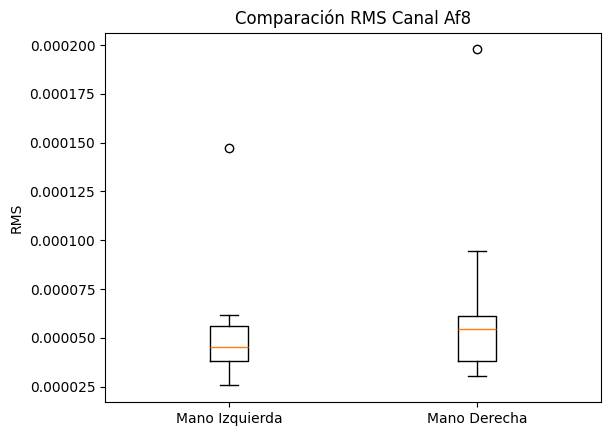

In [106]:
import matplotlib.pyplot as plt

data = [df_T1[canal_top], df_T2[canal_top]]

plt.boxplot(data, labels=["Mano Izquierda","Mano Derecha"])

plt.title(f"Comparación RMS Canal {canal_top}")
plt.ylabel("RMS")

plt.show()

Se generó un diagrama de caja del canal AF8 para comparar la distribución del RMS entre las tareas de imaginería motora de mano izquierda y mano derecha. Se observa una alta superposición entre ambas distribuciones, con medianas similares y variabilidad comparable entre los grupos. Aunque se identifican algunos valores atípicos, estos no generan una separación clara entre las condiciones. Estos resultados coinciden con el análisis estadístico, el cual no encontró diferencias significativas entre los grupos (p > 0.05).